In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor

# Import thư viện XAI
import shap

# Bật tính năng vẽ biểu đồ tương tác của SHAP cho Jupyter Notebook
shap.initjs()

# Đọc và gộp dữ liệu
df_mat = pd.read_csv('Data/student-mat.csv', sep=';')
df_por = pd.read_csv('Data/student-por.csv', sep=';')

df_mat['subject'] = 'Math'
df_por['subject'] = 'Por'
df = pd.concat([df_mat, df_por], ignore_index=True)

print("Đã sẵn sàng dữ liệu cho Explainable AI!")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Đã sẵn sàng dữ liệu cho Explainable AI!


In [2]:
df_xai = df.copy()

# Mã hóa biến phân loại
categorical_cols = df_xai.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in categorical_cols:
    df_xai[col] = le.fit_transform(df_xai[col])

# Tách Features và Target (Bỏ G1, G2 để tránh Data Leakage)
X = df_xai.drop(['G1', 'G2', 'G3'], axis=1)
y = df_xai['G3']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Huấn luyện mô hình Random Forest (Hộp đen)
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

print("Đã huấn luyện xong mô hình Random Forest.")

Đã huấn luyện xong mô hình Random Forest.


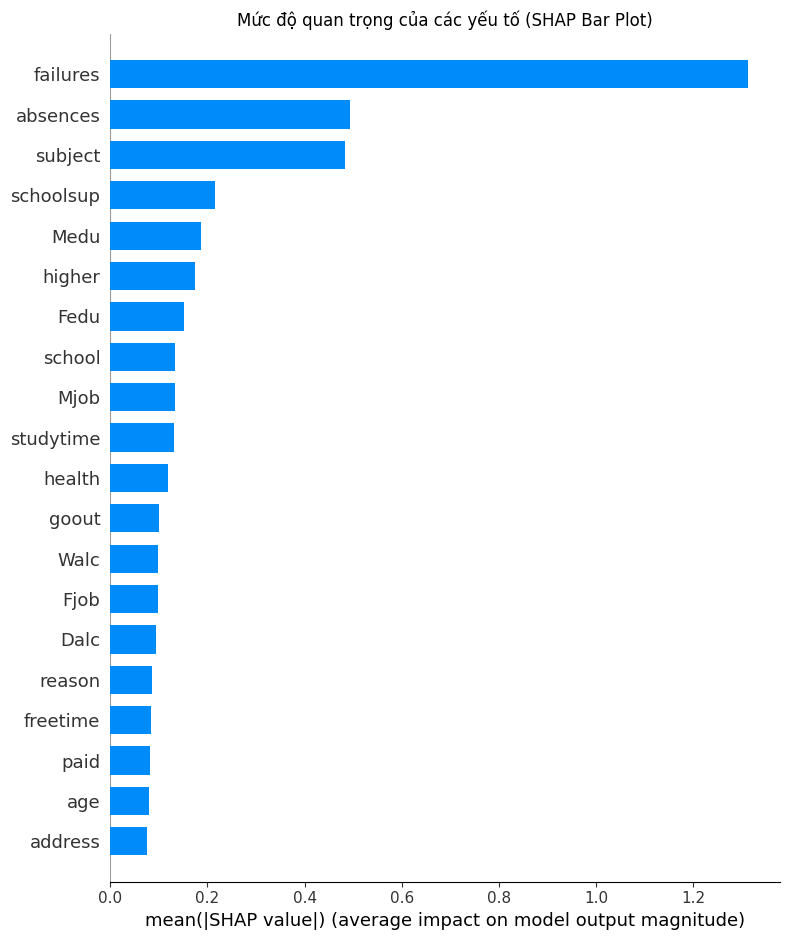

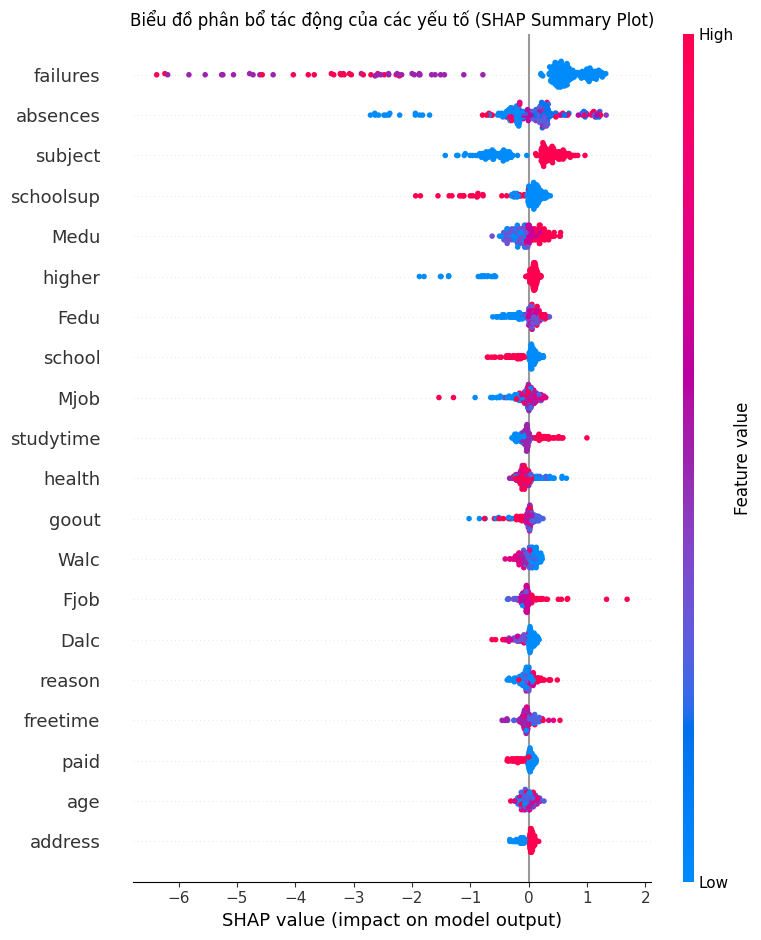

In [3]:
# Khởi tạo SHAP Explainer cho mô hình Random Forest
explainer = shap.TreeExplainer(model_rf)

# Tính toán giá trị SHAP cho tập Test
shap_values = explainer.shap_values(X_test)

# 1. Biểu đồ Tầm quan trọng của Đặc trưng (Feature Importance Bar Plot)
plt.figure(figsize=(8, 6))
plt.title("Mức độ quan trọng của các yếu tố (SHAP Bar Plot)")
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.show()

# 2. Biểu đồ Tổng hợp (Summary Plot) - Cực kỳ chi tiết
plt.figure(figsize=(8, 6))
plt.title("Biểu đồ phân bổ tác động của các yếu tố (SHAP Summary Plot)")
shap.summary_plot(shap_values, X_test, show=False)
plt.show()

Giá trị dự đoán của mô hình cho học sinh này: 9.62
Giá trị trung bình chung của toàn bộ học sinh: 11.40



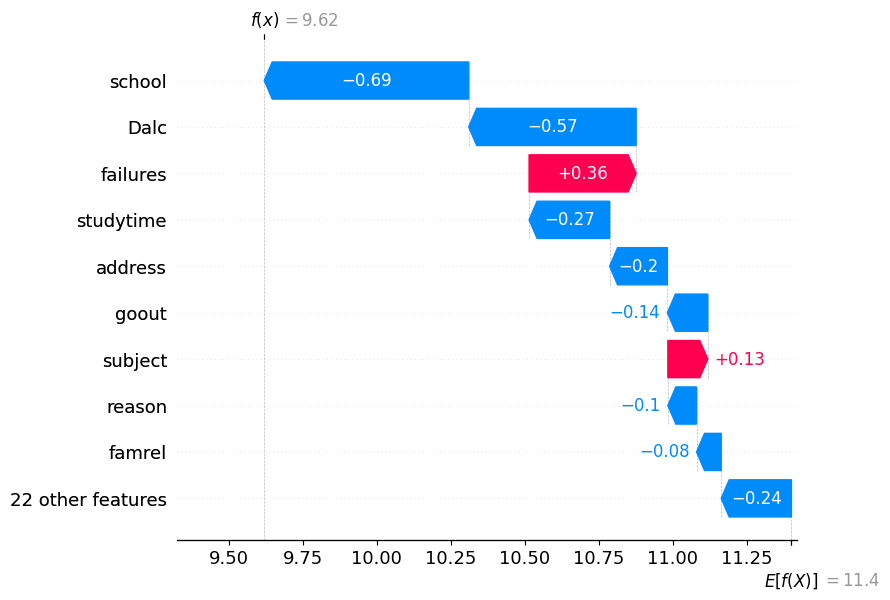

In [4]:
# Chọn 1 học sinh bất kỳ trong tập Test (đổi số 0 thành số khác để xem học sinh khác)
student_index = 0

print(f"Giá trị dự đoán của mô hình cho học sinh này: {model_rf.predict(X_test.iloc[[student_index]])[0]:.2f}")
print(f"Giá trị trung bình chung của toàn bộ học sinh: {explainer.expected_value[0]:.2f}\n")

# Vẽ biểu đồ thác nước (Waterfall) hoặc Force Plot để giải thích
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value[0], 
    shap_values[student_index], 
    feature_names=X_test.columns,
    max_display=10 # Hiển thị 10 yếu tố tác động mạnh nhất
)
plt.show()

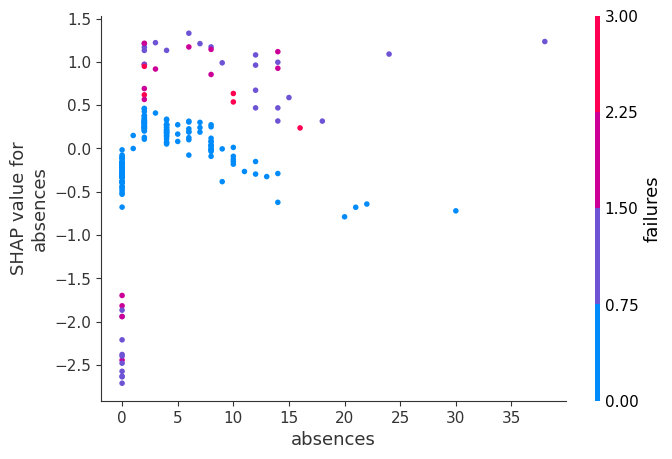

In [5]:
# Phân tích sự tác động của biến 'absences' (số ngày nghỉ)
# Tự động tô màu theo biến có tương tác mạnh nhất với 'absences'
shap.dependence_plot("absences", shap_values, X_test)